In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from reproject.healpix import reproject_to_healpix

import os
print (os.getcwd())
print (os.listdir())

from astropy.io import fits


/home/cbllover/HalfDome
['tSZ_cross_FRB_theta_arcmin_z_dep_vs_random_n1e4_GB_1arcmin.png', 'redshift_distribution_FRB_redshift_logx.png', 'plots\tSZ_Websky_comparison_with.png', 'cosmology.py', 'y_100.fits:Zone.Identifier', 'plots\tSZ_Fullsky_Osato_comparison.png', 'kappa_zs0.5_s100.fits:Zone.Identifier', '.git', 'tmp_dm_beam.jld2', 'tmp_plot_test_local.jl', 'HalfDome_kSZ_nside4096_sigmoid_r0_3_position_hcorr_13Msol_cutoff_HALO.fits', 'halos_websky.hdf5', 'kappa_zs0.5_s100.fits', '=5,', 'cached_kSZ_Websky_tau_base_f_e.jld2', 'other_sim_kSZ_sigmoid.jl', 'cached_kSZ_Websky_tau_base.jld2', 'tSZ_cross_FRB_ell_websky_vs_halfdome.png', 'plots\\kSZ_Osato_comparison.png', 'Websky_tests.ipynb', 'Testing_websky_diff_models.ipynb', 'Classy_SZ_tests.ipynb', 'batched_data', 'cached_tSZ_Websky_cosmo_base_gaussbeam_0p5arcmin.jld2', 'cached_model_density-z_websky.jld2', 'tSZ_cross_FRB_halo_test.jl', 'Halfdome_analysis-checkpoint.ipynb', 'ksz_websky.fits:Zone.Identifier', 'globusconnectpersonal-latest.

# Julia/xgpaint results

In [2]:
def plot_kSZ(fname, title = "kSZ map TOTAL (NSIDE=2048)", unit = r"ΔT, $(\mu K)$", cmap = "plasma", scale = 1):
    # The tSZ Compton-y map (field 0)
    y_map = hp.read_map(fname, field=0, nest=False, dtype=np.float32)
    
    # Plot it directly
    hp.mollview(y_map*scale, title=title, unit=unit, norm="hist", cmap = cmap, format="%.1e")
    hp.graticule()
    plt.show()
    return y_map

In [3]:
def power_spectra_computation(fname):
    data_full = hp.read_map(fname, field=0, nest=False, dtype=np.float32)

    lmax = 3*hp.get_nside(data_full) - 1
    cl = hp.anafast(data_full, lmax=lmax)
    ell = np.arange(len(cl))
    Dl = ell*(ell+1)*cl/(2*np.pi)
    return Dl, ell

In [4]:
def plot_power_spectra(y_map, title = "Power spectrum of total kSZ map"):
    lmax = 3*hp.get_nside(y_map) - 1
    cl = hp.anafast(y_map, lmax=lmax)
    ell = np.arange(len(cl))

    Dl = ell*(ell+1)*cl/(2*np.pi)*10**12
    #Dl = cl/(2*np.pi)*10**12
    plt.loglog(ell, Dl*10**6)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi, (\mu K^2)$")
    plt.xlim((70, 6000))
    plt.title(title)
    plt.show()
    return Dl

In [5]:
import h5py
import numpy as np

path = "/home/cbllover/HalfDome/halos_websky.hdf5"

with h5py.File(path, "r") as f:
    # inspect available datasets
    print(list(f.keys()))
    # ['x', 'y', 'z', 'vx', 'vy', 'vz', 'redshift', 'm200m', 'm200c']

    # read all halo redshifts
    redshift = f["redshift"][:]
    print(redshift.shape, redshift.dtype)

['m200c', 'm200m', 'redshift', 'vx', 'vy', 'vz', 'x', 'y', 'z']
(862923142,) float32


# WEB-sky comparison

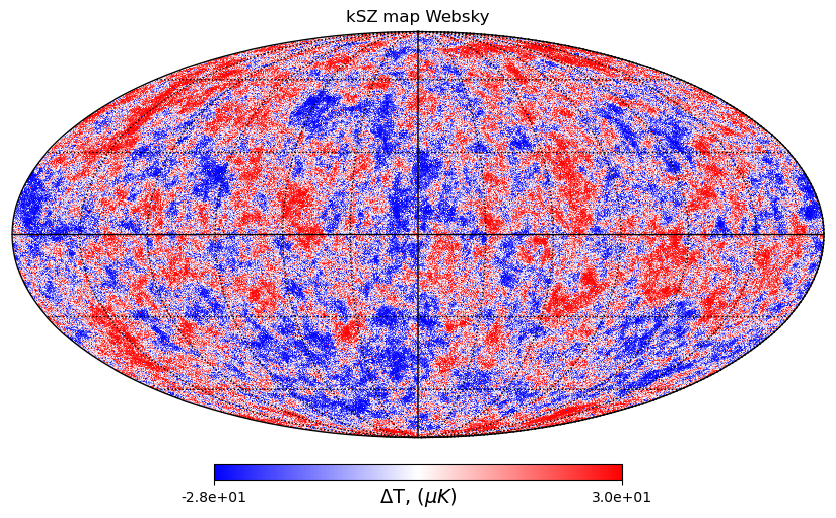

In [6]:

fname = "ksz_websky.fits"
websky_full = plot_kSZ(fname, title  = r"kSZ map Websky", unit = r"ΔT, $(\mu K)$", cmap = "bwr")

In [7]:
fname = "ksz_websky.fits"
Dl1, ell1 = power_spectra_computation(fname)

In [8]:

fname9= "other_sims/148_ksz_healpix_nopell_Nside4096_DeltaT_uK.fits"
Dl9, ell9 = power_spectra_computation(fname9)

In [9]:
fname10 = "other_sims/other_sim_Tcmb_tSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200m.fits"
Dl10, ell10 = power_spectra_computation(fname10)

In [13]:
fname17= "batched_data/websky_kSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200m_BATCHED.fits"
Dl17, ell17 = power_spectra_computation(fname17)

In [52]:
fname18= "batched_data/websky_kSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200c_BATCHED.fits"
Dl18, ell18 = power_spectra_computation(fname18)

In [ ]:
fname19 = "HalfDome_kSZ_nside4096_sigmoid_r0_3_position_normalization_13Msol_cutoff_HALO.fits"
Dl19, ell19 = power_spectra_computation(fname19)

In [100]:
fname22 = "HalfDome_kSZ_nside4096_sigmoid_r0_3_position_hcorr_13Msol_cutoff_HALO.fits"
Dl22, ell22 = power_spectra_computation(fname22)

KeyboardInterrupt: 

In [36]:
fname21 = "batched_data/websky_kSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200c_htest_BATCHED.fits"
Dl21, ell21 = power_spectra_computation(fname21)


KeyboardInterrupt: 

In [11]:
fname23 = "HalfDome_kSZ_nside4096_sigmoid_r0_3_position_phys_units_13Msol_cutoff_HALO.fits"
Dl23, ell23 = power_spectra_computation(fname23)

In [59]:
fname20 = "batched_data/websky_kSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200c_htest_BATCHED_phys_units.fits"
Dl20, ell20 = power_spectra_computation(fname20)

In [95]:


cl_1zp = hp.read_cl("batched_data/websky_kSZ_cl_test_phys_param_base_nside4096_ADRIAN_FIX.fits")[1]  # 1D array
ells_1zp = np.array(range(len(cl_1zp)))
Dl_1zp = ells_1zp*(ells_1zp+1)*cl_1zp/(2*np.pi)

In [8]:
# the comoving units with /(1+z) for veolocities
# websky_kSZ_cl_mass_change_xgpaint_h4_removed

# websky_kSZ_cl_f_b_1pz

# f_b added for kSZ: websky_kSZ_cl_f_b_division.fits

# Adrian's fix of kSZ: websky_kSZ_cl_test_phys_param_base_nside4096_ADRIAN_FIX

# His git code: kSZ_c_l_adrian_fix

# f_e = 0.9 add: websky_kSZ_cl_test_phys_param_base_nside4096_ADRIAN_FIX_f_e09

# Theta cut to adrain fix: websky_kSZ_cl_test_phys_param_base_nside4096_ADRIAN_FIX_theta_cut

cl = hp.read_cl("batched_data/websky_kSZ_cl_test_phys_param_base_nside4096_ADRIAN_FIX_f_e09.fits")[1]  # 1D array
ells_ph = np.array(range(len(cl)))
Dl_ph = ells_ph*(ells_ph+1)*cl/(2*np.pi)

In [5]:
# Osato code and Allsky simulation

fname_as = "HPC_output/Fullsky_ksz_mock_nres12_r000.fits"
Dl_as, ell_as = power_spectra_computation(fname_as)

In [6]:
# Osato code and Allsky simulation

fname_fullsky_kSZ = "other_sims/sims/allsky_HP_kSZ_nres13_r000.fits"
Dl_fullsky_kSZ, ell_fullsky_kSZ = power_spectra_computation(fname_fullsky_kSZ)

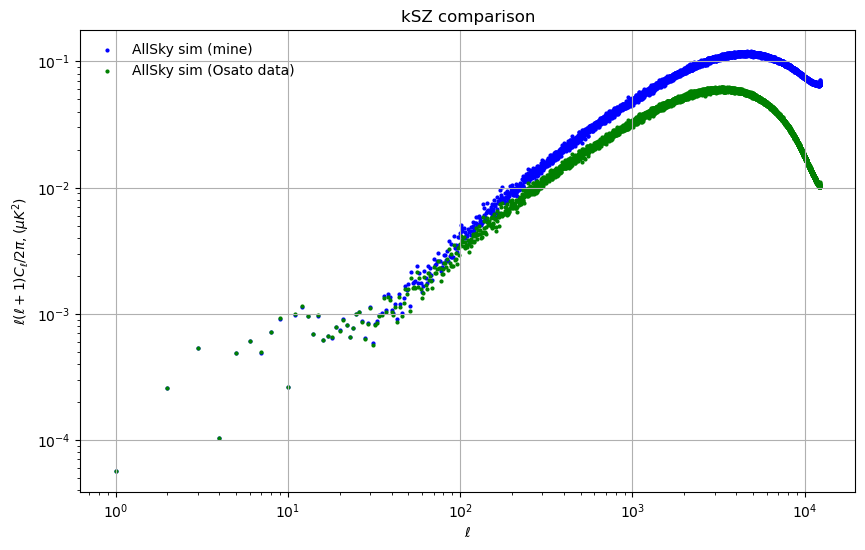

In [49]:
plt.figure(figsize = (10, 6))
factor_mult = (2.7255*1e6)**2
CMB_factor = 1/(2.73**2)
plt.title("kSZ comparison")

# plt.scatter(ell1, Dl1, s = 4, label = "Websky full (LAMBDA)", c= 'grey')
# plt.scatter(ell16, Dl16*factor_mult, s = 4, label = "HalfDome halo $logM_{200c} > 13$", c = "black")
# plt.scatter(ell9, Dl9, s = 4, label = "Simons Observatory Forecasts (2019)", c = "green")
# plt.scatter(ell10, Dl10*factor_mult, s = 4, label = "Sehgal 2010 halo ", c = "blue")
# plt.scatter(ell18, Dl18*factor_mult, s = 4, label = "Websky halo (mine)", c = "purple")
# plt.scatter(ell17, Dl17*factor_mult, s = 4, label = "Websky halo $logM_{200m} > 13$", c = "orange")
# plt.scatter(ell21, Dl21*factor_mult, s = 4, label = "Websky halo, $v_{||}$~ $ h^5 (1+z)$", c = "red")
# plt.scatter(ell23, Dl23*factor_mult, s = 4, label = "HalfDome", c = "brown")
# plt.scatter(ell20, Dl20*factor_mult, s = 4, label = "Websky physical", c = "red")
# plt.scatter(ells_ph, Dl_ph*factor_mult, s = 4, label = "Websky physical", c = "blue")
# plt.scatter(ells_1zp, Dl_1zp*factor_mult, s = 4, label = "Websky xgpaint halo", c = "blue")
plt.scatter(ell_as, Dl_as*1e12, s = 4, label = "AllSky sim (mine)", c = "blue")
plt.scatter(ell_fullsky_kSZ, Dl_fullsky_kSZ*1e12, s = 4, label = "AllSky sim (Osato data)", c = "green")


plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi, (\mu K^2)$")
# plt.xlim((70, 6000))
# plt.ylim((0.1, 2.5))
plt.xscale("log")
plt.yscale("log")
# plt.title(title)
plt.legend(frameon = False)
plt.grid()
plt.savefig("Osato_code_HP_kSZ_comparison.png")
plt.show()

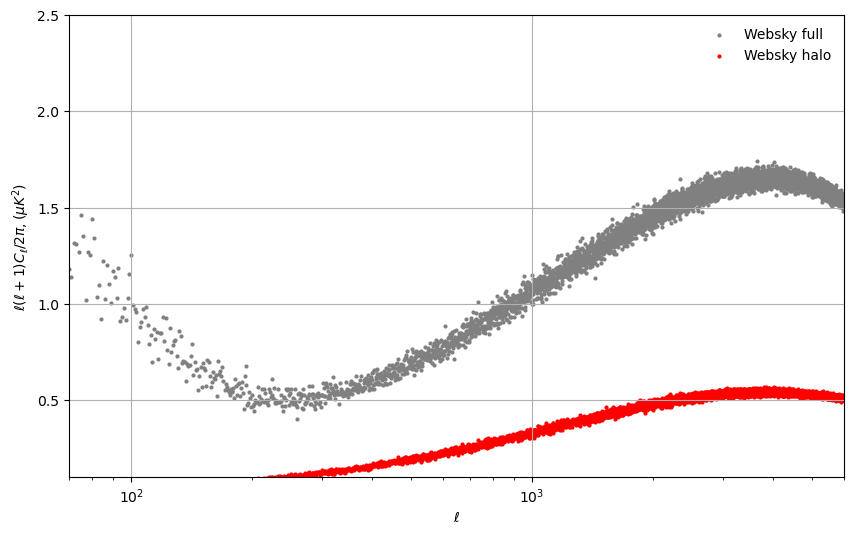

In [9]:
plt.figure(figsize = (10, 6))
factor_mult = (2.7255*1e6)**2
CMB_factor = 1/(2.73**2)
f_b_factor = (0.0486 / (0.2589 + 0.0486))**2

plt.scatter(ell1, Dl1, s = 4, label = "Websky full", c= 'grey')
# plt.scatter(ell16, Dl16*factor_mult, s = 4, label = "HalfDome halo $logM_{200c} > 13$", c = "black")
# plt.scatter(ell9, Dl9, s = 4, label = "Simons Observatory Forecasts (2019)", c = "green")
# plt.scatter(ell10, Dl10*factor_mult, s = 4, label = "Sehgal 2010 halo ", c = "blue")
# plt.scatter(ell18, Dl18*factor_mult, s = 4, label = "Websky halo $logM_{200c} > 13$", c = "purple")
# plt.scatter(ell17, Dl17*factor_mult, s = 4, label = "Websky halo $logM_{200m} > 13$", c = "orange")
plt.scatter(ells_ph, Dl_ph*factor_mult, s = 4, label = r"Websky halo", c = "red")
# plt.scatter(ells_1zp, Dl_1zp*factor_mult, s = 4, label = r"Websky halo Adrian fix", c = "red")




plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi, (\mu K^2)$")
plt.xlim((70, 6000))
plt.ylim((0.1, 2.5))
# plt.yscale("log")
plt.xscale("log")
# plt.title(title)
plt.legend(frameon = False)
plt.grid()
# plt.savefig("kSZ_Adrian_fix_compared_to_full_websky.png")
plt.show()

In [23]:
1/f_b_factor

40.03295991464716

### (Websky has m200m)

Data for other sims from https://lambda.gsfc.nasa.gov/simulation/full_sky_sims_ov.html

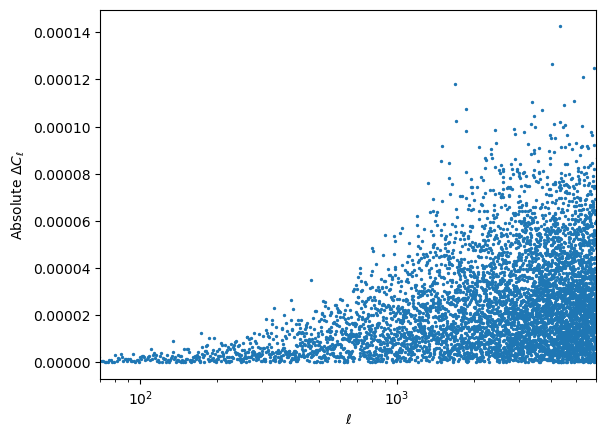

In [24]:
plt.scatter(ell16, abs((Dl16*factor_mult - Dl19*factor_mult)), s = 2, label = "HalfDome M>1e13")
plt.xlim((70, 6000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"Absolute $\Delta C_{\ell}$")
plt.xscale("log")

## Cosmology
#### Websky:
(Ωm,Ωb,σ8,ns,h,τ) =(0.31,0.049,0.81,0.965,0.68,0.055)

Halo mass = 1.2 10^(12) M_sol(z < 4). Up to z = 4.6 it becomes 4e12 M_sol
#### Halfdome:
 h=0.6774, Ωm=0.3089, Ωb=0.0486, σ8=0.8159, ns=0.9667, Mν=0
 
 Halo Mass = 1.95 * 10^10 M_sol (in reality its around 5e12 M_sol from histograms of data)
 

In [ ]:
# fname2 = "y_tSZ_small_sigmoid.fits"
# Dl3, ell3 = power_spectra_computation(fname2)

# fname3 = "y_tSZ_nside4096_sigmoid_m1e13_corr_units.fits"


# Dl4, ell4 = power_spectra_computation(fname3)

# fname4 = "y_tSZ_nside4096_sigmoid_m1e13.fits"

# Dl5, ell5 = power_spectra_computation(fname4)

# fname5 = "y_tSZ_nside4096_sigmoid_m1e13_corr_units_increased_acc.fits"

# Dl6, ell6 = power_spectra_computation(fname5)

# fname6 = "y_tSZ_nside1024_sigmoid_m1e13_corr_units_increased_acc.fits"
# Dl7, ell7 = power_spectra_computation(fname6)

# fname7= "y_tSZ_nside4096_sigmoid_13Msol_cutoff_HALO _m200m.fits"
# Dl8, ell8 = power_spectra_computation(fname7)


# fname11 = "Tcmb_tSZ_nside4096_sigmoid_r03_13Msol_cutoff_HALO.fits"
# Dl11, ell11 = power_spectra_computation(fname11)


# fname12= "Tcmb_tSZ_nside4096_battaglia_13Msol_cutoff_HALO.fits"
# Dl12, ell12= power_spectra_computation(fname12)


# fname13= "Tcmb_tSZ_nside4096_sigmoid_r0_3_va_13Msol_cutoff_HALO.fits"
# Dl13, ell13= power_spectra_computation(fname13)


# fname14= "Tcmb_tSZ_nside4096_sigmoid_r0_3_dva_13Msol_cutoff_HALO.fits"
# Dl14, ell14= power_spectra_computation(fname14)

# fname15= "Tcmb_tSZ_nside4096_sigmoid_r0_3_hcorr_13Msol_cutoff_HALO.fits"
# Dl15, ell15= power_spectra_computation(fname15)

# fname17= "batched_data/websky_kSZ_nside4096_sigmoid_13Msol_cutoff_HALO_m200m_BATCHED.fits"
# Dl17, ell17 = power_spectra_computation(fname17)

# tSZ tests

In [5]:
fname_tsz2 = "batched_data/websky_tSZ_nside4096_13Msol_cutoff_HALO.fits"
Dl_tsz2, ell_tsz2 = power_spectra_computation(fname_tsz2)

In [6]:
fname_tsz = "HalfDome_y_tSZ_mass_corr.fits"
Dl_tsz, ell_tsz = power_spectra_computation(fname_tsz)

In [5]:
fname3 = "other_sims/tsz_8192.fits"
Dl3, ell3 = power_spectra_computation(fname3)

In [18]:
fname4 = "batched_data/websky_tSZ_nside4096_13Msol_cutoff_HALO_different_mass.fits"
Dl4, ell4 = power_spectra_computation(fname4)

In [ ]:
fname4 = "batched_data/websky_tSZ_nside4096_13Msol_cutoff_HALO_different_mass.fits"
Dl4, ell4 = power_spectra_computation(fname4)

In [21]:
fname5 = "batched_data/websky_tSZ_nside4096_13Msol_cutoff_HALO_m200m_no_mlimits.fits"
Dl5, ell5 = power_spectra_computation(fname5)

In [6]:
# websky_tSZ_cl_m200m_redshift_density     # an attempt to have critical density evolving with redshift, but 10^6 discrepancy, not right
# websky_tSZ_cl_m200c   # not really m200c, it is m200m but with M*h. Rest is unchanged. Has a good match, but at ell = 3000 lower and small ell bigger than default
# websky_tSZ_cl_m200c_adr_coord     # Higher amplitude at all scales, but this is M200c, Msun, so must be approx correcy
# websky_tSZ_cl_m200c_default_sett.fits     # Changed gamma par to -0.35, underlying model with 15.7 Msol integration limit,included mass limit of log = 13Msol
# websky_tSZ_cl_m200c_test_phys_param.fits    # Added bunch of physical parameter change options, but the results should be the same
# websky_tSZ_cl_m200c_test_phys_param.fits    # This is from HPC cluster, trying to see if everything is as it should be
cl = hp.read_cl("HPC_output/websky/websky_tSZ_cl_m200c_test_phys_param.fits")[1]  # 1D array
ells_ph = np.array(range(len(cl)))
Dl_ph = ells_ph*(ells_ph+1)*cl/(2*np.pi)

In [6]:
cl_soc = hp.read_cl("batched_data/websky_tSZ_cl_m200c_default_sett_SOConverter.fits")[1]  # 1D array
ells_soc = np.array(range(len(cl_soc)))
Dl_soc = ells_soc*(ells_soc+1)*cl_soc/(2*np.pi)

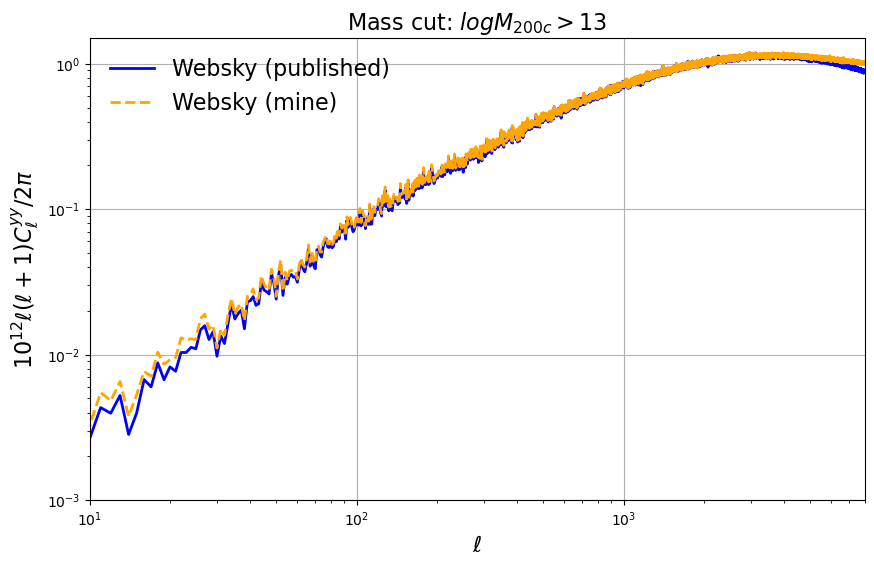

In [11]:
plt.figure(figsize = (10, 6))


# plt.plot(ell_tsz, Dl_tsz*10**12, linewidth = 2, label = "HalfDome", c= 'purple')
# plt.plot(ell_tsz2, Dl_tsz2*10**12, "--", linewidth = 2, label = "Websky XGPaint", c= 'blue')
# plt.plot(ell4, Dl4*10**12, linewidth = 2, label = "Websky no mass corr", c= 'green')
plt.plot(ell3, Dl3*10**12, linewidth = 2, label = "Websky (published)", c= 'blue')
# plt.plot(ell5, Dl5*10**12, "--", linewidth = 2, label = "Websky M*h", c= 'red')
plt.plot(ells_ph, Dl_ph*10**12, "--", linewidth = 2, label = "Websky (mine)", c= 'orange')
# plt.plot(ells_soc, Dl_soc*10**12, "--", linewidth = 2, label = "Websky XGPaint (mine)", c= 'black')


plt.xlabel(r"$\ell$", fontsize= 16); plt.ylabel(r"$10^{12} \ell(\ell+1)C^{yy}_\ell/2\pi $", fontsize = 16)
plt.xlim((10, 8000))
plt.ylim((1e-3, 1.5))
plt.xscale("log")
plt.yscale("log")
# plt.title(title)
plt.legend(frameon = False, fontsize = 16)
plt.grid()
plt.title("Mass cut: $logM_{200c} > 13$", fontsize =16)
# plt.savefig("plots\tSZ_HalfDome_vs_Websky.png")
plt.show()

In [14]:
ells_ph

array([    0,     1,     2, ..., 12285, 12286, 12287])

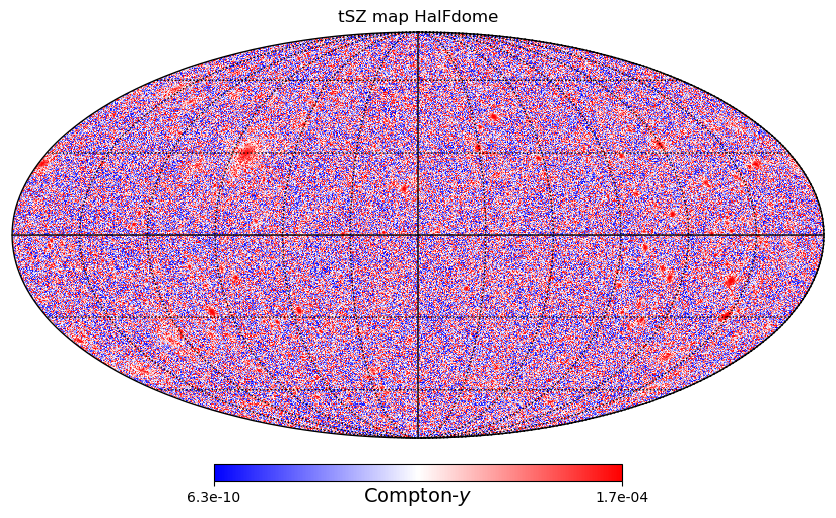

In [6]:

fname = "HalfDome_y_tSZ_mass_corr.fits"
websky_full = plot_kSZ(fname, title  = r"tSZ map HalFdome", unit = r"Compton-$y$", cmap = "bwr")

/tmp/ipykernel_45/3560451146.py:28: RuntimeWarning: invalid value encountered in divide
  pct = abs(Dl_ph/Dl3[:len(ells_ph)] - 1)


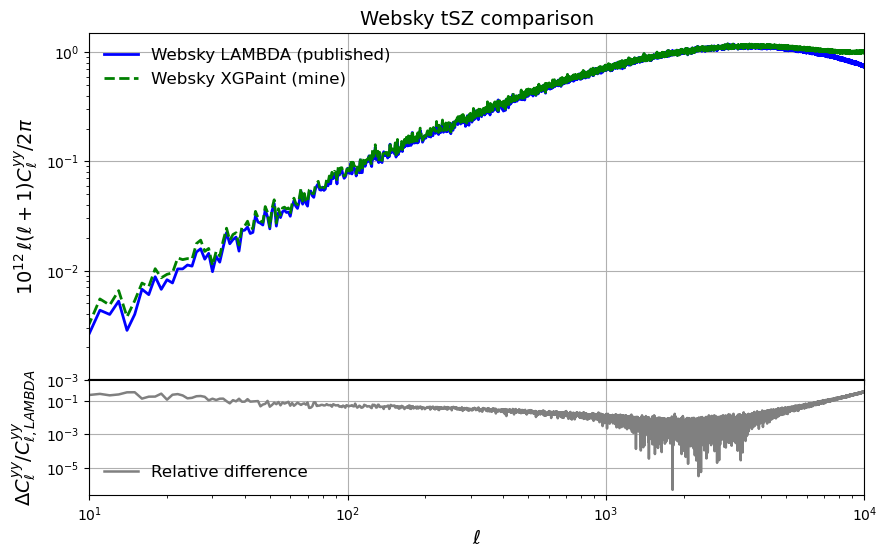

In [35]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
)

# -------------------
# Top panel: spectra
# -------------------
ax1.plot(ell3, Dl3*1e12, lw=2, label="Websky LAMBDA (published)", c="blue")
ax1.plot(ells_ph, Dl_ph*1e12, ls="--", lw=2, label="Websky XGPaint (mine)", c="green")

ax1.set_ylabel(r"$10^{12}\,\ell(\ell+1)C^{yy}_\ell/2\pi$", fontsize=14)
ax1.set_yscale("log")
ax1.set_ylim(1e-3, 1.5)
ax1.grid(True)
ax1.legend(frameon=False, fontsize=12)
ax1.set_title(r"Websky tSZ comparison", fontsize=14)

# -------------------
# Bottom panel: ratio-like (around 1), like your example image
# -------------------
# If ell-grids differ, you should interpolate Dl_soc onto ell3 before doing this.
# ratio = Dl_soc / Dl3

pct = abs(Dl_ph/Dl3[:len(ells_ph)] - 1)
ax2.plot(ells_ph, pct, lw=1.8, c="grey", label="Relative difference")
ax2.plot(ells_ph, np.zeros(len(ells_ph)), "--", c = "black")
ax2.set_ylabel("% diff", fontsize=14)
# (then choose a sensible y-lim for your data)


ax2.set_ylabel(r"$\Delta C^{yy}_\ell / C^{yy}_{\ell, LAMBDA}$", fontsize=14)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_yscale("log")
# ax2.set_ylim(0.9, 1.1)  # tweak to taste
ax2.grid(True)
ax2.legend(frameon=False, fontsize=12)

# Shared x formatting
ax2.set_xscale("log")
ax2.set_xlim(10, 10000)

# Make the divider line look like the example
ax1.spines["bottom"].set_linewidth(1.5)
ax2.spines["top"].set_linewidth(1.5)
ax1.tick_params(labelbottom=False)  # hide top x tick labels
plt.savefig("plots\tSZ_Websky_comparison_with.png")
plt.show()


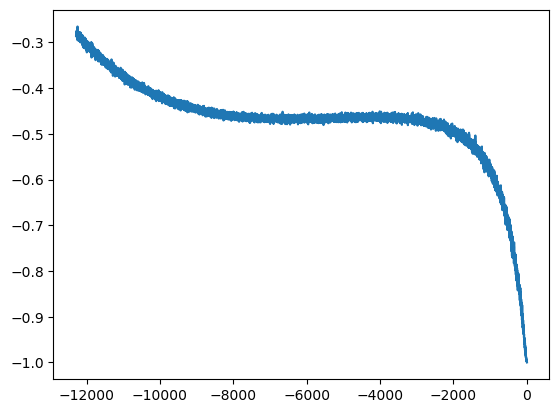

In [29]:
plt.plot(1 - ells_ph, pct)


In [15]:
G = 6.67 * 10**(-11)
factor = 3/ (8*3.14*G)*100
print ("{:.2e}".format(factor))

1.79e+11


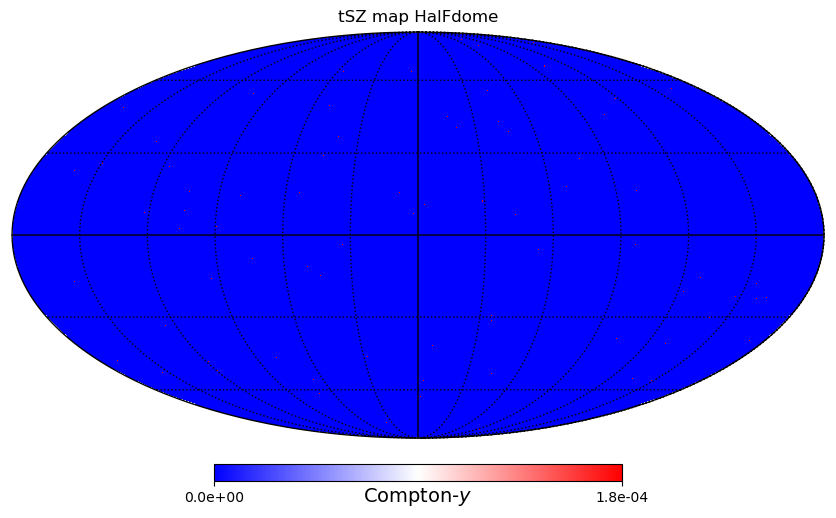

In [25]:
fname = "../Osato_pasting/Pastel_public/Websky_tsz_mock_nres12_r000_SMALL.fits"
websky_full = plot_kSZ(fname, title  = r"tSZ map HalFdome", unit = r"Compton-$y$", cmap = "bwr")

# Osato code

In [15]:
fname_as_tSZ = "HPC_output/Fullsky_tsz_mock_nres12_r000.fits"
Dl_as_tSZ, ell_as_tSZ = power_spectra_computation(fname_as_tSZ)

In [16]:
fname_fullskyHP = r"other_sims/sims/allsky_HP_tSZ_nres13_r000.fits"
Dl_fullskyHP, ell_fullskyHP = power_spectra_computation(fname_fullskyHP)

/tmp/ipykernel_6632/4221997045.py:29: RuntimeWarning: invalid value encountered in divide
  pct_tSZ = Dl_as_tSZ/Dl_fullskyHP - 1
/tmp/ipykernel_6632/4221997045.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(frameon=False, fontsize=12)


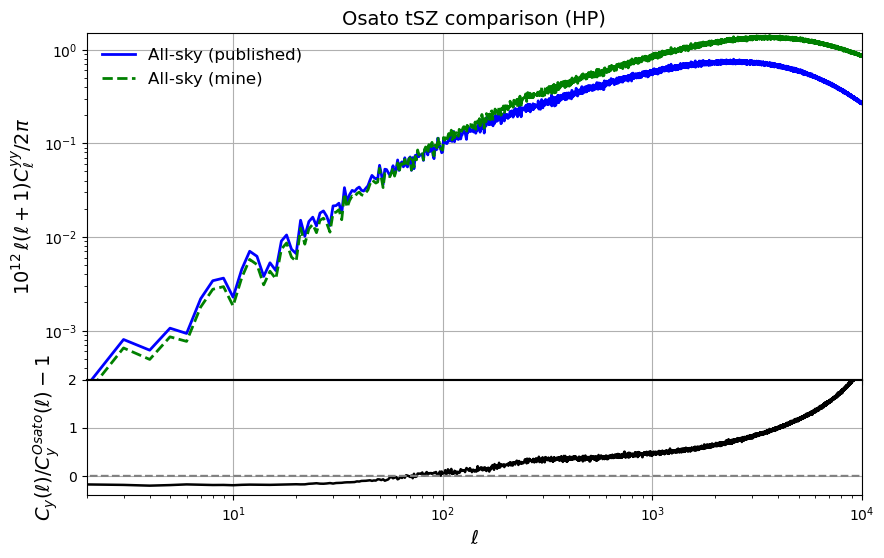

In [68]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
)

# -------------------
# Top panel: spectra
# -------------------
ax1.plot(ell_fullskyHP, Dl_fullskyHP*1e12, lw=2, label="All-sky (published)", c="blue")
ax1.plot(ell_as_tSZ, Dl_as_tSZ*1e12, ls="--", lw=2, label="All-sky (mine)", c="green")

ax1.set_ylabel(r"$10^{12}\,\ell(\ell+1)C^{yy}_\ell/2\pi$", fontsize=14)
ax1.set_yscale("log")
ax1.set_ylim(3e-4, 1.5)
ax1.grid(True)
ax1.legend(frameon=False, fontsize=12)
ax1.set_title(r"Osato tSZ comparison (HP)", fontsize=14)

# -------------------
# Bottom panel: ratio-like (around 1), like your example image
# -------------------
# If ell-grids differ, you should interpolate Dl_soc onto ell3 before doing this.
# ratio = Dl_as_tSZ / Dl_fullskyHP

pct_tSZ = abs(((Dl_as_tSZ - Dl_fullskyHP) / (Dl_as_tSZ + 1e-12)))
pct_tSZ = Dl_as_tSZ/Dl_fullskyHP - 1
ax2.plot(ell_as_tSZ, pct_tSZ, lw=1.8, c="black")
ax2.plot(ell_as_tSZ, np.zeros(len(ell_as_tSZ)), "--", c = "gray")
ax2.set_ylabel("% diff", fontsize=14)
# (then choose a sensible y-lim for your data)


ax2.set_ylabel(r"$C_y(\ell) / C^{Osato}_y(\ell) - 1$", fontsize=14)
ax2.set_xlabel(r"$\ell$", fontsize=14)
# ax2.set_yscale("log")
ax2.set_ylim(-0.4, 2)  # tweak to taste
ax2.grid(True)
ax2.legend(frameon=False, fontsize=12)

# Shared x formatting
ax2.set_xscale("log")
ax2.set_xlim(2, 10000)

# Make the divider line look like the example
ax1.spines["bottom"].set_linewidth(1.5)
ax2.spines["top"].set_linewidth(1.5)
ax1.tick_params(labelbottom=False)  # hide top x tick labels
plt.savefig("plots\tSZ_Fullsky_Osato_comparison.png")
plt.show()


/tmp/ipykernel_6632/1246412764.py:34: RuntimeWarning: invalid value encountered in divide
  pct_kSZ = Dl1/Dl2 - 1
/tmp/ipykernel_6632/1246412764.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(frameon=False, fontsize=12)


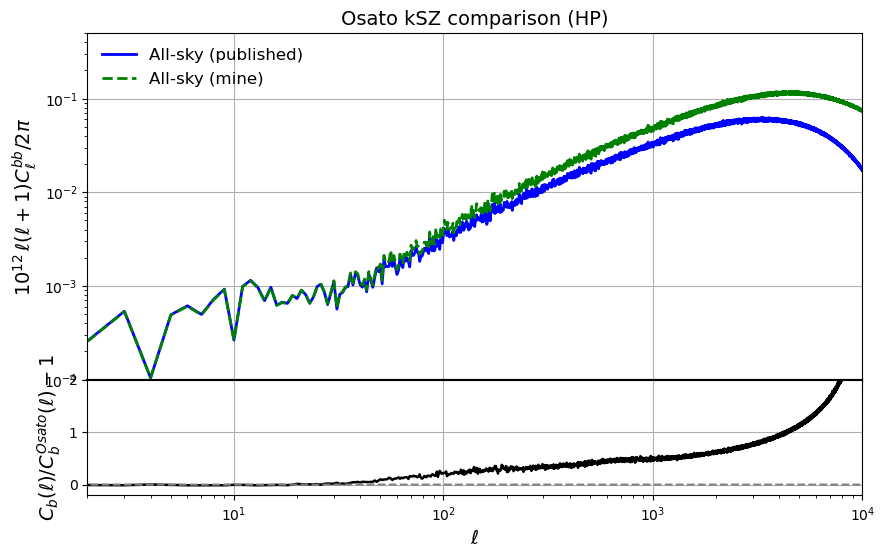

In [74]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
)

ell1 = ell_as
ell2 = ell_fullsky_kSZ
Dl1 = Dl_as
Dl2 = Dl_fullsky_kSZ

# -------------------
# Top panel: spectra
# -------------------
ax1.plot(ell2, Dl2*1e12, lw=2, label="All-sky (published)", c="blue")
ax1.plot(ell1, Dl1*1e12, ls="--", lw=2, label="All-sky (mine)", c="green")

ax1.set_ylabel(r"$10^{12}\,\ell(\ell+1)C^{bb}_\ell/2\pi$", fontsize=14)
ax1.set_yscale("log")
ax1.set_ylim(1e-4, 5e-1)
ax1.grid(True)
ax1.legend(frameon=False, fontsize=12)
ax1.set_title(r"Osato kSZ comparison (HP)", fontsize=14)

# -------------------
# Bottom panel: ratio-like (around 1), like your example image
# -------------------
# If ell-grids differ, you should interpolate Dl_soc onto ell3 before doing this.
# ratio = Dl_as_tSZ / Dl_fullskyHP

pct_kSZ = abs(((Dl1 - Dl2) / (Dl1 + 1e-12)))
pct_kSZ = Dl1/Dl2 - 1

ax2.plot(ell1, pct_kSZ, lw=1.8, c="black")
ax2.plot(ell1, np.zeros(len(ell1)), "--", c = "grey")
ax2.set_ylabel("% diff", fontsize=14)
# (then choose a sensible y-lim for your data)


ax2.set_ylabel(r"$C_b(\ell) / C^{Osato}_b(\ell) - 1$", fontsize=14)
ax2.set_xlabel(r"$\ell$", fontsize=14)
# ax2.set_yscale("log")
ax2.set_ylim(-0.2, 2)  # tweak to taste
ax2.grid(True)
ax2.legend(frameon=False, fontsize=12)

# Shared x formatting
ax2.set_xscale("log")
ax2.set_xlim(2, 10000)

# Make the divider line look like the example
ax1.spines["bottom"].set_linewidth(1.5)
ax2.spines["top"].set_linewidth(1.5)
ax1.tick_params(labelbottom=False)  # hide top x tick labels
plt.savefig("plots\kSZ_Osato_comparison.png")
plt.show()


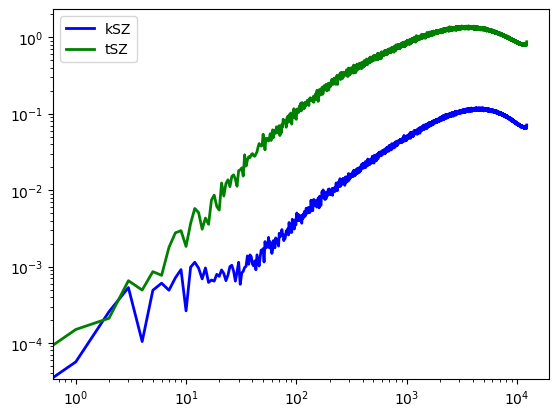

In [37]:
plt.plot(ell1, Dl1*1e12, linewidth = 2, label = "kSZ", c= 'blue')
plt.plot(ell_as_tSZ, Dl_as_tSZ*1e12, linewidth = 2, label = "tSZ", c= 'green')
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [55]:
ell_v = np.log(ell1)
pct_v = np.log(pct_tSZ)

m, b = np.polyfit(ell_v, pct_v, 1)
pct_fit = m * ell_v + b

plt.plot(ell_v, pct_fit, lw=1.8, c="grey", label="Linear fit")

/tmp/ipykernel_6632/2423919517.py:1: RuntimeWarning: divide by zero encountered in log
  ell_v = np.log(ell1)
/tmp/ipykernel_6632/2423919517.py:2: RuntimeWarning: divide by zero encountered in log
  pct_v = np.log(pct_tSZ)


LinAlgError: SVD did not converge in Linear Least Squares

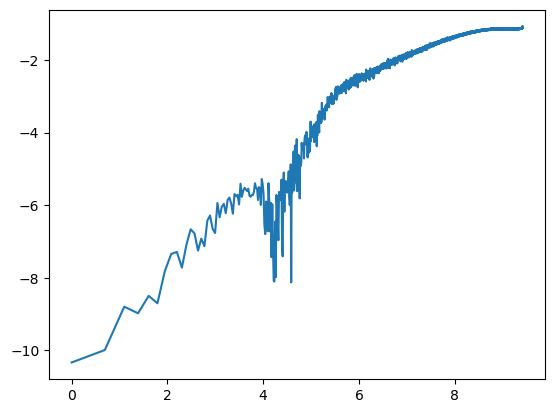

In [57]:
plt.plot(ell_v, pct_v)

In [12]:
# test of nside

def read_cl(path = "path"):
    cl_soc = hp.read_cl(path)[1]  # 1D array
    ells_soc = np.array(range(len(cl_soc)))
    Dl_soc = ells_soc*(ells_soc+1)*cl_soc/(2*np.pi)
    return ells_soc, Dl_soc

In [13]:
# websky_tSZ_cl_m200c_test_phys_param_base_nside8192
# websky_tSZ_cl_m200c_test_phys_param_base_nside4096
# websky_tSZ_cl_m200c_test_phys_param_base_nside2048

ell2048, cl2048 = read_cl(path = "batched_data/websky_tSZ_cl_m200c_test_phys_param_base_nside2048.fits")
ell4096, cl4096 = read_cl(path = "batched_data/websky_tSZ_cl_m200c_test_phys_param_base_nside4096.fits")
ell8192, cl8192 = read_cl(path = "batched_data/websky_tSZ_cl_m200c_test_phys_param_base_nside8192.fits")

/tmp/ipykernel_19626/1505511518.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(frameon=False, fontsize=12)


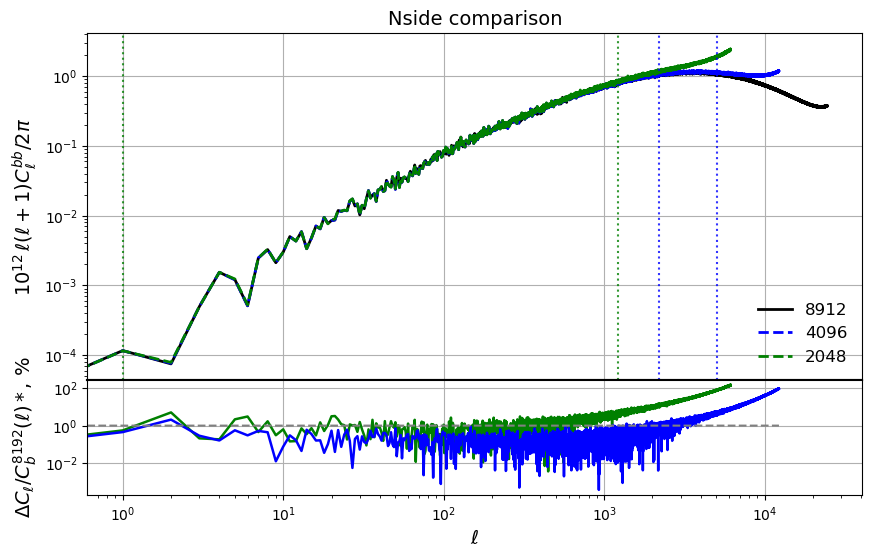

In [99]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}
)

ell1 = ell2048
ell2 = ell4096
ell3 = ell8192
Dl1 = cl2048
Dl2 = cl4096
Dl3 = cl8192

# -------------------
# Top panel: spectra
# -------------------
ax1.plot(ell3, Dl3*1e12, lw=2, label="8912", c="black")
ax1.plot(ell2, Dl2*1e12, ls="--", lw=2, label="4096", c="blue")
ax1.plot(ell1, Dl1*1e12, ls="--", lw=2, label="2048", c="green")



ax1.set_ylabel(r"$10^{12}\,\ell(\ell+1)C^{bb}_\ell/2\pi$", fontsize=14)
ax1.set_yscale("log")
# ax1.set_ylim(1e-4, 5e-1)
ax1.grid(True)
ax1.legend(frameon=False, fontsize=12)
ax1.set_title(r"Nside comparison", fontsize=14)

# -------------------
# Bottom panel: ratio-like (around 1), like your example image
# -------------------
# If ell-grids differ, you should interpolate Dl_soc onto ell3 before doing this.
# ratio = Dl_as_tSZ / Dl_fullskyHP

pct_1 = abs((-Dl3[:len(Dl1)] + Dl1)/(Dl3[:len(Dl1)] + 1e-20)*100)
pct_2 = abs((-Dl3[:len(Dl2)] + Dl2)/(Dl3[:len(Dl2)] + 1e-20) *100)

ax2.plot(ell1, pct_1, lw=1.8, c="green")
ax2.plot(ell2, pct_2, lw=1.8, c="blue")

ax2.plot(ell2, 1*np.ones(len(ell2)), "--", c = "grey")
ax2.set_ylabel("% diff", fontsize=14)
# (then choose a sensible y-lim for your data)


ax2.set_ylabel(r"$\Delta C_{\ell}/ C^{8192}_b(\ell)*$, %", fontsize=14)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_yscale("log")
# ax2.set_ylim(-0.2, 2)  # tweak to taste
ax2.grid(True)
ax2.legend(frameon=False, fontsize=12)

# Shared x formatting
ax2.set_xscale("log")
# ax2.set_xlim(2, 10000)

# vertical lines
for x, c in [(e1_1, "green"), (e1_5, "green"),
             (e2_1, "blue"),  (e2_5, "blue")]:
    if np.isfinite(x):
        ax1.axvline(x, linestyle=":", color=c, alpha=0.8)

# Make the divider line look like the example
ax1.spines["bottom"].set_linewidth(1.5)
ax2.spines["top"].set_linewidth(1.5)
ax1.tick_params(labelbottom=False)  # hide top x tick labels
plt.savefig("plots\nside_comparison.png")
plt.show()


2048 → 1%: 1  5%: 1226
4096 → 1%: 2199  5%: 5063


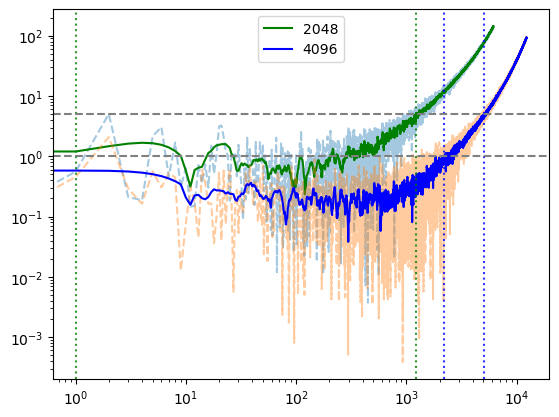

In [97]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# --- smoothing ---
y1 = signal.savgol_filter(pct_1, 20, 3)  # window must be odd
y2 = signal.savgol_filter(pct_2, 20, 3)

# --- helper to get first crossing ---
def first_cross(ell, y, thr):
    idx = np.where(y > thr)[0]
    if idx.size == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return ell[0]
    # linear interpolation for better estimate
    x0, x1 = ell[i-1], ell[i]
    y0, y1 = y[i-1], y[i]
    return i

# --- crossings ---
e1_1 = first_cross(ell1, y1, 1.0)
e1_5 = first_cross(ell1, y1, 5.0)

e2_1 = first_cross(ell2, y2, 1.0)
e2_5 = first_cross(ell2, y2, 5.0)

print("2048 → 1%:", e1_1, " 5%:", e1_5)
print("4096 → 1%:", e2_1, " 5%:", e2_5)

# --- plot ---
plt.plot(ell1, pct_1, "--", alpha=0.4)
plt.plot(ell1, y1, c="green", label="2048")

plt.plot(ell2, pct_2, "--", alpha=0.4)
plt.plot(ell2, y2, c="blue", label="4096")

# vertical lines
for x, c in [(e1_1, "green"), (e1_5, "green"),
             (e2_1, "blue"),  (e2_5, "blue")]:
    if np.isfinite(x):
        plt.axvline(x, linestyle=":", color=c, alpha=0.8)

# optional labels
plt.axhline(1, ls="--", c="grey")
plt.axhline(5, ls="--", c="grey")

plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

In [64]:
y1

First ℓ where smoothed |%diff| > 1%:
  2048: 24.527767919305145
  4096: 2503.405177215747


In [73]:
y2

array([ 0.57303243,  0.57934856,  0.57414331, ..., 92.63504722,
       92.3589778 , 92.01063793])

# tSZ x FRB

In [5]:
cl_1zp = hp.read_cl("batched_data/websky_tSZ_x_FRB_cl_base_nfrb5000_seed42_nside4096.fits")[1]  # 1D array
ells_1zp = np.array(range(len(cl_1zp)))
Dl_1zp = ells_1zp*(ells_1zp+1)*cl_1zp/(2*np.pi)

In [6]:
cl_2zp = hp.read_cl("batched_data/websky_tSZ_x_FRB_cl_base_nfrb10000_seed42_nside4096.fits")[1]  # 1D array
ells_2zp = np.array(range(len(cl_2zp)))
Dl_2zp = ells_2zp*(ells_2zp+1)*cl_2zp/(2*np.pi)

In [19]:
cl_71 = hp.read_cl("batched_data/websky_tSZ_x_FRB_selected_DM_cl_base_nfrb71_seed42_nside4096.fits")[1]  # 1D array
ells_71 = np.array(range(len(cl_71)))
Dl_71 = ells_71*(ells_71+1)*cl_71/(2*np.pi)

In [24]:
cl_5 = hp.read_cl("batched_data/websky_tSZ_x_FRB_selected_DM_cl_base_nfrb100000_seed42_nside4096.fits")[1]  # 1D array
ells_5 = np.array(range(len(cl_5)))
Dl_5 = ells_5*(ells_5+1)*cl_5/(2*np.pi)

In [40]:

cl_7 = hp.read_cl("batched_data/websky_tSZ_x_FRB_selected_DM_cl_base_nfrb10000000_seed42_nside4096.fits")[1]  # 1D array
ells_7 = np.array(range(len(cl_7)))
Dl_7 = ells_7*(ells_7+1)*cl_7/(2*np.pi)

In [100]:

cl_7_new = hp.read_cl("batched_data/websky_tSZ_x_FRB_selected1_DM_cl_base_nfrb10000000_seed42_nside4096.fits")[1]  # 1D array
ells_7_new = np.array(range(len(cl_7_new)))
Dl_7_new = ells_7_new*(ells_7_new+1)*cl_7_new/(2*np.pi)

In [55]:
# HalfDome
cl_5h = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nfrb100000_seed42_nside4096.fits")[1]  # 1D array
ells_5h = np.array(range(len(cl_5h)))
Dl_5h = ells_5h*(ells_5h+1)*cl_5h/(2*np.pi)

In [57]:
# HalfDome
cl_5w = hp.read_cl("batched_data/websky_tSZ_x_FRB_selected1_DM_cl_base_nfrb100000_seed42_nside4096.fits")[1]  # 1D array
ells_5w = np.array(range(len(cl_5w)))
Dl_5w = ells_5w*(ells_5w+1)*cl_5w/(2*np.pi)

In [63]:
# HalfDome
cl_5hz = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nfrb100000_seed42_redshift_zcut0p5_zmax2p0_nside4096.fits")[1]  # 1D array
ells_5hz = np.array(range(len(cl_5hz)))
Dl_5hz = ells_5hz*(ells_5hz+1)*cl_5hz/(2*np.pi)

In [68]:
# HalfDome
cl_4hz = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nfrb10000_seed42_redshift_zcut0p5_zmax2p5_nside4096.fits")[1]  # 1D array
ells_4hz = np.array(range(len(cl_4hz)))
Dl_4hz = ells_4hz*(ells_4hz+1)*cl_4hz/(2*np.pi)

In [72]:
# HalfDome
cl_4hz_gb = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nfrb10000_seed42_redshift_zcut0p5_zmax2p5_nside4096_gaussian_beam.fits")[1]  # 1D array
ells_4hz_gb = np.array(range(len(cl_4hz_gb)))
Dl_4hz_gb = ells_4hz_gb*(ells_4hz_gb+1)*cl_4hz_gb/(2*np.pi)

In [120]:
# HalfDome
cl_4hz_gb = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nfrb10000_seed42_redshift_zcut0p5_zmax2p5_nside4096_gaussian_beam.fits")[1]  # 1D array
ells_4hz_gb = np.array(range(len(cl_4hz_gb)))
Dl_4hz_gb = ells_4hz_gb*(ells_4hz_gb+1)*cl_4hz_gb/(2*np.pi)

In [121]:
# HalfDome
cl_5hz_gb = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_gaussbeam_0p5arcmin_nfrb100000_seed42_redshift_zcut0p5_zmax2p5_nside4096.fits")[1]  # 1D array
ells_5hz_gb = np.array(range(len(cl_5hz_gb)))
Dl_5hz_gb = ells_5hz_gb*(ells_5hz_gb+1)*cl_4hz_gb/(2*np.pi)

In [5]:
# HalfDome
cl_4hz_1gb = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_gaussbeam_map_1p0arcmin_nfrb10000_seed42_redshift_zcut0p5_zmax2p5_nside4096.fits")[1]  # 1D array
ells_4hz_1gb = np.array(range(len(cl_4hz_1gb)))
Dl_4hz_1gb = ells_4hz_1gb*(ells_4hz_1gb+1)*cl_4hz_1gb/(2*np.pi)

In [14]:
# HalfDome
cl_4hz_1p6gb_random = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_tszbeam_1p6arcmin_dmbeam_none_nfrb10000_seed42_random_zcut0p5_zmax2p5_nside4096.fits")[1]  # 1D array
ells_4hz_1p6gb_random = np.array(range(len(cl_4hz_1p6gb_random)))
Dl_4hz_1p6gb_random = ells_4hz_1p6gb_random*(ells_4hz_1p6gb_random+1)*cl_4hz_1p6gb_random/(2*np.pi)

In [12]:
# HalfDome
cl_4hz_random = hp.read_cl("batched_data/halfdome_tSZ_x_FRB_selected1_DM_cl_base_nobeam_nfrb10000_seed42_random_zcut0p5_zmax2p5_nside4096.fits")[1]  # 1D array
ells_4hz_random = np.array(range(len(cl_4hz_random)))
Dl_4hz_random = ells_4hz_random*(ells_4hz_random+1)*cl_4hz_random/(2*np.pi)

In [9]:
theta_arcmin = np.full_like(ells_2zp, np.nan, dtype=float)
theta_arcmin[1:] = 10800.0 / ells_2zp[1:]   # skip ell=0

valid = ells_2zp > 0
theta_arcmin = 10800.0 / ells_2zp[valid]
Dl_plot = Dl_2zp[valid]

In [88]:
print (Dl_4hz[:4]*factor_mult, ells_4hz[:4])

[ 0.00000000e+00  2.64887794e-07 -1.86709089e-04 -9.04187249e-05] [0 1 2 3]


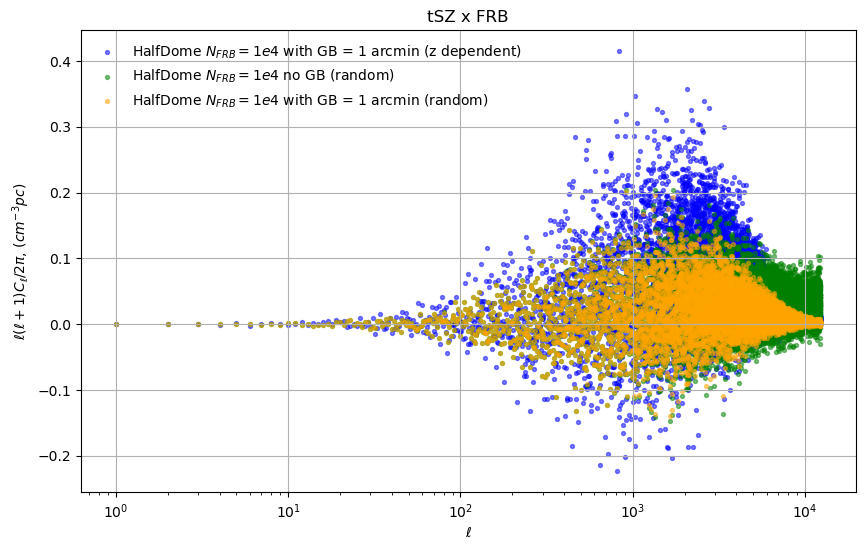

In [16]:
plt.figure(figsize = (10, 6))
factor_mult = (2.7255*1e6)
CMB_factor = 1/(2.73**2)
plt.title("tSZ x FRB")

# plt.scatter(ells_1zp, Dl_1zp*factor_mult, s = 4, label = r"$N_{FRB} = 5000$", c = "blue")
# plt.scatter(ells_71, Dl_71*factor_mult, s = 4, label = r"$N_{FRB} = 71$ (Planck number of FRBs)", c = "blue", alpha = 0.5)

# plt.scatter(ells_5, Dl_5*factor_mult, s = 4, label = r"$N_{FRB} = 1e5$ (SKA)", c = "red", alpha = 0.5)

# plt.scatter(ells_4hz, Dl_4hz*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$",
#             c = "blue", alpha = 0.5)

# plt.scatter(ells_5w, Dl_5w*factor_mult, s = 4, label = r"Websky $N_{FRB} = 1e5$ (SKA)", c = "green", alpha = 0.5)

# plt.scatter(ells_4hz_gb, Dl_4hz_gb*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$ with Gaussian beam", c = "green", alpha = 0.5)

# plt.scatter(ells_5hz_gb, Dl_5hz_gb*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e5$ with Gaussian beam", c = "pink", alpha = 0.5)

plt.scatter(ells_4hz_1gb, Dl_4hz_1gb*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (z dependent)", c = "blue", alpha = 0.5)

plt.scatter(ells_4hz_random, Dl_4hz_random*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$ no GB (random)", c = "green", alpha = 0.5)

plt.scatter(ells_4hz_1p6gb_random, Dl_4hz_1p6gb_random*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (random)", c = "orange", alpha = 0.5)


# plt.scatter(ells_5h, Dl_5h*factor_mult, s = 4, label = r"HalfDome $N_{FRB} = 1e5$ (SKA)", c = "pink", alpha = 0.5)

# plt.scatter(ells_5hz, Dl_5hz*factor_mult, s = 4, label = r"HalfDome $N_{FRB} = 1e5$ (SKA), z dependent",
#             c = "orange", alpha = 0.5)



# plt.scatter(ells_7, Dl_7*factor_mult, s = 4, label = r"$N_{FRB} = 1e7$", c = "green", alpha = 0.5)

# plt.scatter(ells_7_new, Dl_7_new*factor_mult, s = 4, label = r"$N_{FRB} = 1e7$ (arbitrary)", c = "black", alpha = 0.5)
# # 
# plt.scatter(ells_2zp, Dl_2zp*factor_mult, s = 4, label = r"$N_{FRB} = 10000$", c = "red")



plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$, $(cm^{-3}pc)$")
# plt.xlim((1, 20))
# plt.ylim((-0.00001, 0.00001))
plt.xscale("log")
# plt.yscale("log")
# plt.title(title)
plt.legend(frameon = False)
plt.grid()
plt.savefig("tSZ_cross_FRB_z_dep_vs_random_n1e4_GB_1arcmin.png")
plt.show()

In [43]:
import numpy as np

def bin_cl(
    cl,
    delta_ell=10,
    ell_min=None,
    ell_max=None,
    weight_by_modes=True,
    binning="linear",
    n_log_bins=12,
):
    """
    Bin C_ell values either linearly or logarithmically.

    Parameters
    ----------
    cl : array-like
        Input C_ell array, indexed by ell.
    delta_ell : int, optional
        Linear bin width in ell, used if binning="linear".
    ell_min : int, optional
        Minimum ell to include.
    ell_max : int or None, optional
        Maximum ell to include. If None, uses len(cl)-1.
    weight_by_modes : bool, optional
        If True, use weights (2 ell + 1). Otherwise uniform weights.
    binning : {"linear", "log"}, optional
        Type of binning.
    n_log_bins : int, optional
        Number of logarithmic bins, used if binning="log".

    Returns
    -------
    ell_binned : ndarray
        Weighted mean ell in each bin.
    cl_binned : ndarray
        Weighted mean C_ell in each bin.
    cl_sigma : ndarray
        Weighted standard deviation of C_ell values in each bin.
    """
    cl = np.asarray(cl, dtype=float)
    ells = np.arange(cl.size)

    if ell_max is None:
        ell_max = cl.size - 1

    if ell_min < 0:
        raise ValueError("ell_min must be >= 0.")
    if ell_max < ell_min:
        raise ValueError("ell_max must be >= ell_min.")

    ell_binned = []
    cl_binned = []
    cl_sigma = []

    if binning == "linear":
        bin_edges = np.arange(ell_min, ell_max + delta_ell, delta_ell)
        if bin_edges[-1] <= ell_max:
            bin_edges = np.append(bin_edges, ell_max + 1)

    elif binning == "log":
        if ell_min < 1:
            raise ValueError('For binning="log", ell_min must be >= 1.')
        # +1 on upper edge helps include ell_max cleanly for integer ell
        bin_edges = np.logspace(
            np.log10(ell_min),
            np.log10(ell_max + 1),
            n_log_bins + 1
        )
    else:
        raise ValueError("binning must be 'linear' or 'log'.")

    for i in range(len(bin_edges) - 1):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        # left-inclusive, right-exclusive; include ell_max in the final bin
        if i == len(bin_edges) - 2:
            mask = (ells >= lo) & (ells <= ell_max)
        else:
            mask = (ells >= lo) & (ells < hi)

        if not np.any(mask):
            continue

        ell_bin = ells[mask]
        cl_bin = cl[mask]

        if weight_by_modes:
            w = 2 * ell_bin + 1
        else:
            w = np.ones_like(ell_bin, dtype=float)

        wsum = np.sum(w)
        ell_mean = np.sum(ell_bin * w) / wsum
        cl_mean = np.sum(cl_bin * w) / wsum

        cl_var = np.sum(w * (cl_bin - cl_mean) ** 2) / wsum
        cl_std = np.sqrt(cl_var)

        ell_binned.append(ell_mean)
        cl_binned.append(cl_mean)
        cl_sigma.append(cl_std)

    return np.array(ell_binned), np.array(cl_binned), np.array(cl_sigma)

In [55]:
ell_bin, cl_bin, cl_sigma = bin_cl(Dl_4hz_1p6gb_random, delta_ell = 10, ell_max=None, ell_min = 1,
    weight_by_modes=True,
    binning="log",
    n_log_bins=20)

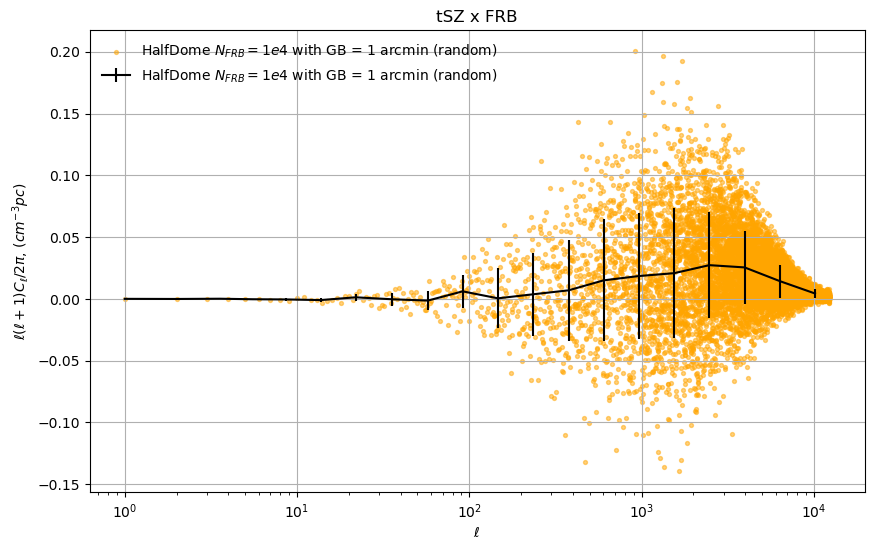

In [56]:
plt.figure(figsize = (10, 6))
factor_mult = (2.7255*1e6)
CMB_factor = 1/(2.73**2)
plt.title("tSZ x FRB")

plt.scatter(ells_4hz_1p6gb_random, Dl_4hz_1p6gb_random*factor_mult, s = 8, label = r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (random)", c = "orange", alpha = 0.5)
plt.errorbar(ell_bin, cl_bin*factor_mult, yerr= cl_sigma*factor_mult, label = r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (random)", c = "black")
# plt.scatter(ell_bin, cl_bin*factor_mult, c = "black", s= 10)





plt.xlabel(r"$\ell$"); plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$, $(cm^{-3}pc)$")
# plt.xlim((1, 20))
# plt.ylim((-0.00001, 0.00001))
plt.xscale("log")
# plt.yscale("log")
# plt.title(title)
plt.legend(frameon = False)
plt.grid()
# plt.savefig("tSZ_cross_FRB_z_dep_vs_random_n1e4_GB_1arcmin.png")
plt.show()

/tmp/ipykernel_433417/3195095931.py:8: RuntimeWarning: divide by zero encountered in divide
  theta_random_arcmin = 10800.0 / np.array(ells_4hz_1p6gb_random)


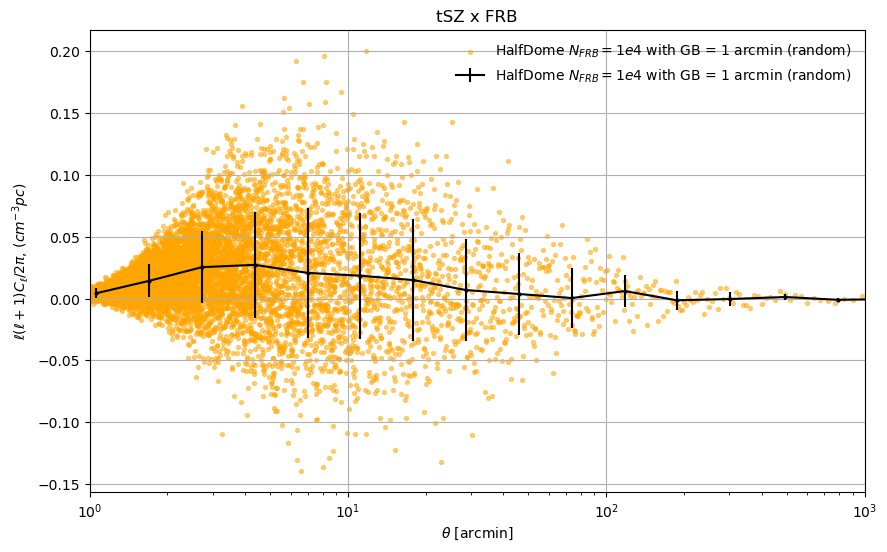

In [58]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
factor_mult = 2.7255e6

# approximate conversion: theta [arcmin] ~ 10800 / ell
theta_random_arcmin = 10800.0 / np.array(ells_4hz_1p6gb_random)
theta_bin_arcmin    = 10800.0 / np.array(ell_bin)

plt.title("tSZ x FRB")

plt.scatter(
    theta_random_arcmin,
    Dl_4hz_1p6gb_random * factor_mult,
    s=8,
    label=r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (random)",
    c="orange",
    alpha=0.5
)

plt.errorbar(
    theta_bin_arcmin,
    cl_bin * factor_mult,
    yerr = cl_sigma*factor_mult,
    label=r"HalfDome $N_{FRB} = 1e4$ with GB = 1 arcmin (random)",
    c="black"
)

plt.scatter(
    theta_bin_arcmin,
    cl_bin * factor_mult, s = 4, 
    c="black"
)

plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$, $(cm^{-3}pc)$")

plt.xscale("log")
# plt.gca().invert_xaxis()   # optional: small theta on the right, large theta on the left

plt.legend(frameon=False)
plt.grid()
plt.xlim((1, 1000))
# plt.savefig("tSZ_cross_FRB_theta_arcmin_z_dep_vs_random_n1e4_GB_1arcmin.png")
plt.show()

# THe paper used 133 FRBs, so that's why it might be amplitude lower

### Have to change to redshift and mass dependence (there was a paper with gaussian around z~1.5 peak for redshift, not sure about mass

### Have to check anyway if the halo assignemnt is correct (fixed)

### Have to add the gaussian beam for the noise of SO and DSA

In [76]:
1/60

0.016666666666666666